## Imports

In [1]:
import numpy as np
import cv2  # For Sobel operator and image filtering
from scipy.ndimage import convolve

## Sobel Operator for Gradient Computation

In [2]:
def compute_gradient(image):
    # Apply Sobel filter to compute gradients
    grad_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    gradient = np.sqrt(grad_x**2 + grad_y**2)
    return gradient

## Guided Image Filter

In [3]:
def guided_filter(I, p, radius, epsilon):
    mean_I = cv2.boxFilter(I, -1, (radius, radius))
    mean_p = cv2.boxFilter(p, -1, (radius, radius))
    mean_Ip = cv2.boxFilter(I * p, -1, (radius, radius))
    cov_Ip = mean_Ip - mean_I * mean_p

    mean_II = cv2.boxFilter(I * I, -1, (radius, radius))
    var_I = mean_II - mean_I * mean_I

    a = cov_Ip / (var_I + epsilon)
    b = mean_p - a * mean_I

    mean_a = cv2.boxFilter(a, -1, (radius, radius))
    mean_b = cv2.boxFilter(b, -1, (radius, radius))

    return mean_a * I + mean_b

## Prefilter Features

In [4]:
def prefilter_features(features):
    # Compute gradient for guidance
    gradients = [compute_gradient(f) for f in features]
    guidance_image = np.max(gradients, axis=0)
    
    # Apply guided filtering to features
    prefiltered_features = [guided_filter(f, guidance_image, radius=7, epsilon=1e-3) for f in features]
    return prefiltered_features, guidance_image

## Adaptive Filtering with Parameter Selection

In [5]:
def adaptive_filtering(image, features, guidance_image, spatial_params, feature_params):
    filtered_results = []
    for sp_param in spatial_params:
        for ft_param in feature_params:
            # Apply cross-bilateral filtering
            filtered = guided_filter(image, guidance_image, radius=int(sp_param), epsilon=ft_param)
            filtered_results.append(filtered)
    return filtered_results

## Removing Spike Noise

In [6]:
def remove_spike_noise(image, gradients, threshold=3.0):
    mean = cv2.boxFilter(image, -1, (5, 5))
    std_dev = np.sqrt(cv2.boxFilter(image**2, -1, (5, 5)) - mean**2)
    spikes = np.abs(image - mean) > (std_dev * threshold)

    # Downweight spikes
    cleaned_image = np.where(spikes, mean, image)
    return cleaned_image

## Main Pipeline

In [11]:
def monte_carlo_denoising(noisy_image, features):
    # Prefilter features
    prefiltered_features, guidance_image = prefilter_features(features)
    
    # Adaptive filtering
    spatial_params = [50, 100, 5, 10000]
    feature_params = [0.1, 0.2, 0.3]
    filtered_images = adaptive_filtering(noisy_image, prefiltered_features, guidance_image, spatial_params, feature_params)

    # Remove spike noise
    final_image = remove_spike_noise(filtered_images[-1], guidance_image)
    return final_image

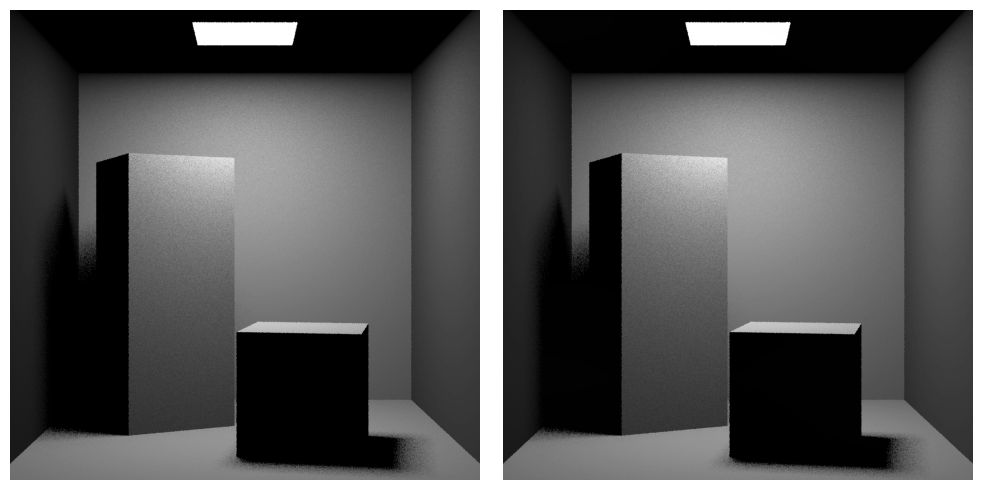

In [12]:
# Example noisy image and feature arrays
noisy_image = cv2.imread('../media/10.png', cv2.IMREAD_GRAYSCALE)  # Load as grayscale
features = [
    cv2.imread('../media/depth.png', cv2.IMREAD_GRAYSCALE),  # Feature 1
    cv2.imread('../media/normal.png', cv2.IMREAD_GRAYSCALE),  # Feature 2
    cv2.imread('../media/texture.png', cv2.IMREAD_GRAYSCALE)   # Feature 3
]

# Apply denoising
denoised_image = monte_carlo_denoising(noisy_image, features)
inverted_image = 1 - denoised_image

# Visualize result
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(noisy_image,cmap='gray')
ax[0].axis('off')
ax[1].imshow(inverted_image,cmap='gray')
ax[1].axis('off')
plt.tight_layout()
plt.show()